### Import lib

In [1]:
import os
import glob
import ctypes
import site
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image



import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_i
from tensorflow.keras.layers import RandomFlip, RandomRotation, Dense, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

I0000 00:00:1774970105.670347   26257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774970106.370764   26257 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774970108.857366   26257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### setting up dataset

In [2]:
images_fp = './images'

In [ ]:
image_names = [os.path.basename(file) for file in glob.glob(os.path.join(images_fp, '*.jpg'))]

In [4]:
len(image_names)

7390

In [5]:
raw_labels = ['_'.join(name.split('_')[:-1]) for name in image_names]
len(set(raw_labels)), sorted(set(raw_labels))[:10]

(37,
 ['Abyssinian',
  'Bengal',
  'Birman',
  'Bombay',
  'British_Shorthair',
  'Egyptian_Mau',
  'Maine_Coon',
  'Persian',
  'Ragdoll',
  'Russian_Blue'])

In [6]:
# Show a small sample of parsed labels
raw_labels[:20]

['samoyed',
 'samoyed',
 'english_setter',
 'Siamese',
 'Abyssinian',
 'keeshond',
 'staffordshire_bull_terrier',
 'Abyssinian',
 'Russian_Blue',
 'British_Shorthair',
 'pug',
 'chihuahua',
 'chihuahua',
 'Birman',
 'keeshond',
 'german_shorthaired',
 'great_pyrenees',
 'Bengal',
 'Persian',
 'great_pyrenees']

In [7]:
# Keep only the original 16 target classes
class_names = [
    'Abyssinian',
    'Bengal',
    'Birman',
    'Bombay',
    'British_Shorthair',
    'Egyptian_Mau',
    'american_bulldog',
    'american_pit_bull_terrier',
    'basset_hound',
    'beagle',
    'boxer',
    'chihuahua',
    'english_cocker_spaniel',
    'english_setter',
    'german_shorthaired',
    'great_pyrenees',
]
label_to_idx = {label: idx for idx, label in enumerate(class_names)}

print('num_target_classes =', len(class_names))
print(class_names)

num_target_classes = 16
['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees']


In [8]:
# Check how many samples belong to the 16 selected classes
total_images = len(image_names)
recognized_images = sum(
    1 for n in image_names if '_'.join(n.split('_')[:-1]) in label_to_idx
)
print('total_images =', total_images)
print('selected_class_images =', recognized_images)
print('excluded_images =', total_images - recognized_images)

total_images = 7390
selected_class_images = 3200
excluded_images = 4190


In [9]:
features = []
encoded_labels = []
IMAGE_SIZE = (224, 224)

for name in image_names:
    label = '_'.join(name.split('_')[:-1])
    if label not in label_to_idx:
        continue

    label_encoded = label_to_idx[label]
    img = load_img(os.path.join(images_fp, name))
    img = tf.image.resize_with_pad(
        img_to_array(img, dtype='uint8'),
        *IMAGE_SIZE
    ).numpy().astype('uint8')

    features.append(np.array(img))
    encoded_labels.append(label_encoded)

print('loaded_images_for_16_classes =', len(features))

I0000 00:00:1774970114.448326   26257 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


loaded_images_for_16_classes = 3200


In [10]:
features_array = np.array(features)
labels_array = np.array(encoded_labels)

features_array.shape, labels_array.shape

((3200, 224, 224, 3), (3200,))

In [11]:
labels_one_hot = pd.get_dummies(labels_array)
labels_one_hot = labels_one_hot.reindex(columns=range(len(class_names)), fill_value=0)

labels_one_hot

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3196,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3197,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [12]:

# Train = 60% + val = 20% and Test: 20%
X_train, X_test, y_train, y_test = train_test_split(features_array, labels_one_hot, test_size=0.2, random_state=42)


In [13]:

# 80%
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)


In [14]:

data_augmentation = Sequential([RandomFlip("horizontal_and_vertical"), RandomRotation(0.2)])
prediction_layers = Dense(16, activation='softmax')



In [15]:


resnet_model = ResNet50(include_top=False, pooling='avg', weights='imagenet')
resnet_model.trainable = False
preprocess_input = pp_i


In [16]:

# Build model
inputs = Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = resnet_model(x, training=False)
x = Dropout(0.2)(x)
outputs = prediction_layers(x)
model = Model(inputs, outputs)


In [17]:
model.compile(
    optimizer=Adam(),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

In [18]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
model_history = model.fit(
    x= X_train, y= y_train,
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10


I0000 00:00:1774970173.756121   36325 cuda_dnn.cc:461] Loaded cuDNN version 92000


60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step - accuracy: 0.4771 - loss: 1.7355 - val_accuracy: 0.8438 - val_loss: 0.5518
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.7406 - loss: 0.7787 - val_accuracy: 0.8844 - val_loss: 0.3661
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.8099 - loss: 0.5884 - val_accuracy: 0.8984 - val_loss: 0.3144
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.8354 - loss: 0.4997 - val_accuracy: 0.9156 - val_loss: 0.2942
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.8432 - loss: 0.4676 - val_accuracy: 0.9094 - val_loss: 0.2736
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.8526 - loss: 0.4227 - val_accuracy: 0.9109 - val_loss: 0.2575
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.8734 - loss: 0.3935 - val_accuracy: 0.9125 - val_loss: 0.2673
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.8901 - loss: 0.3417 - val_accuracy: 0.9031 - va

In [20]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']


Text(0.5, 1.0, 'Training and Validation Loss')

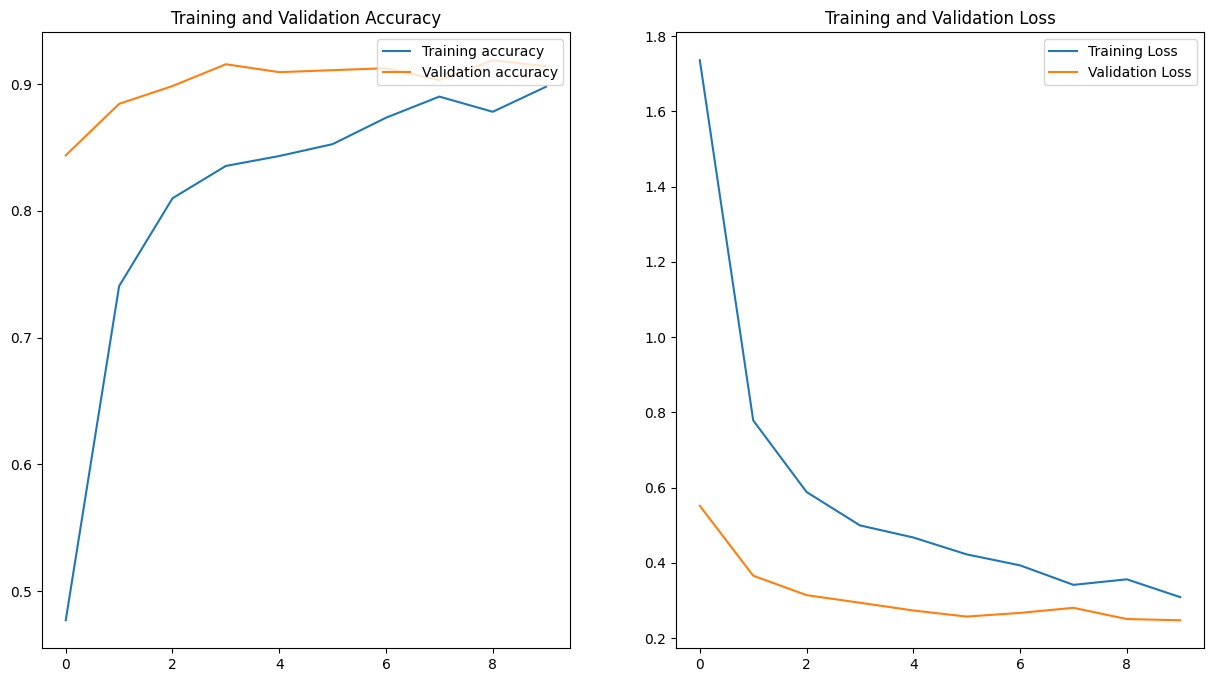

In [21]:

epochs_range = range(10)
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

In [22]:
model.evaluate(X_test, y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9250 - loss: 0.2490


[0.24900908768177032, 0.925000011920929]

In [23]:
y_pred = model.predict(X_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step


In [24]:
y_pred

array([[1.7177332e-04, 1.5182829e-06, 9.9172276e-01, ..., 4.2207964e-04,
        1.4677161e-06, 1.6648866e-03],
       [1.0364120e-01, 1.5403806e-01, 2.6760455e-02, ..., 5.0637349e-03,
        1.1766173e-03, 1.7795626e-04],
       [9.6483575e-03, 2.8923587e-03, 2.3548071e-04, ..., 1.2705673e-03,
        1.9497687e-01, 8.7300818e-03],
       ...,
       [7.0300703e-05, 2.4581937e-05, 4.0032205e-04, ..., 1.1809011e-04,
        1.2569063e-03, 4.5897413e-04],
       [2.8277583e-08, 3.5632704e-06, 3.5902108e-06, ..., 2.2848230e-04,
        5.8320304e-04, 1.6552085e-05],
       [2.8973136e-06, 6.2422681e-05, 1.7880856e-08, ..., 1.3240236e-04,
        9.9605918e-01, 2.0648251e-08]], shape=(640, 16), dtype=float32)

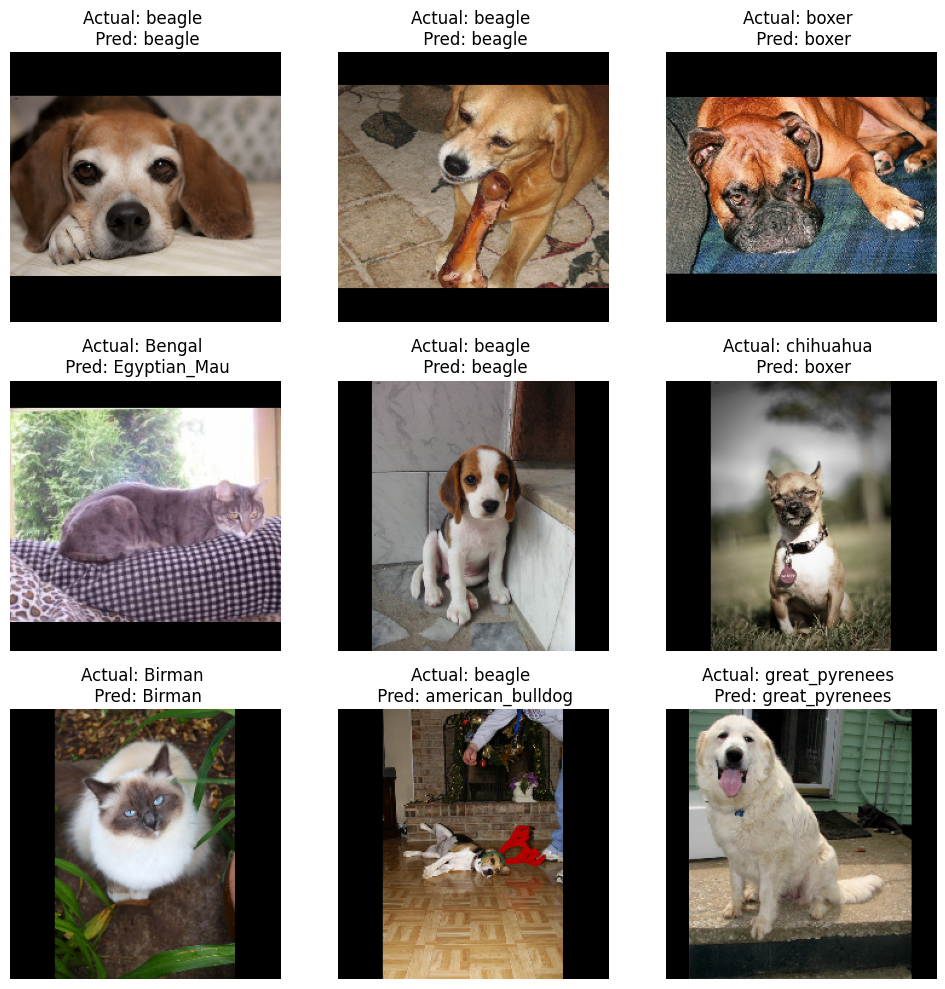

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded labels to class indices
y_true = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Map class indices to class names
y_true_labels = [class_names[i] for i in y_true]
y_pred_labels = [class_names[i] for i in y_pred_classes]

# Number of images to display
n = 9
n = min(n, len(X_test))

# Randomly select image indices without replacement
rng = np.random.default_rng()
random_indices = rng.choice(len(X_test), size=n, replace=False)

plt.figure(figsize=(10,10))

for plot_idx, sample_idx in enumerate(random_indices):
    plt.subplot(3, 3, plot_idx + 1)
    
    # Show image
    plt.imshow(X_test[sample_idx])
    plt.axis('off')
    
    # Title: Actual vs Predicted labels
    plt.title(f"Actual: {y_true_labels[sample_idx]} \n Pred: {y_pred_labels[sample_idx]}")

plt.tight_layout()
plt.show()